**BITCOIN PRICE PREDICTION**


In [ ]:
# STEP 1: IMPORT REQUIRED LIBRARIES
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


from statsmodels.tsa.stattools import adfuller
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.statespace.sarimax import SARIMAX


from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, mean_absolute_error
from sklearn.ensemble import GradientBoostingRegressor


import warnings
warnings.filterwarnings('ignore')

In [ ]:
# STEP 2: LOAD THE DATASET
df = pd.read_csv('BTC-USD.csv')

df['Date'] = pd.to_datetime(df['Date'], dayfirst=True)
df.set_index('Date', inplace=True)

print(df.head())
print(df.info())

                  Open        High         Low       Close   Adj Close  \
Date                                                                     
2014-10-10  364.687012  375.066986  352.963013  361.562012  361.562012   
2014-10-11  361.362000  367.191010  355.950989  362.299011  362.299011   
2014-10-12  362.605988  379.433014  356.144012  378.549011  378.549011   
2014-10-13  377.920990  397.226013  368.897003  390.414001  390.414001   
2014-10-14  391.691986  411.697998  391.324005  400.869995  400.869995   

                Volume  
Date                    
2014-10-10  43665700.0  
2014-10-11  13345200.0  
2014-10-12  17552800.0  
2014-10-13  35221400.0  
2014-10-14  38491500.0  
<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 3566 entries, 2014-10-10 to 2024-07-14
Data columns (total 6 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   Open       3566 non-null   float64
 1   High       3566 non-null   float64
 2   Low        3566 n

In [ ]:
df.columns = df.columns.str.strip()

df = df.fillna(method='ffill')
df = df[~df.index.duplicated()]

In [ ]:
print(df.columns)


Index(['Open', 'High', 'Low', 'Close', 'Adj Close', 'Volume'], dtype='object')


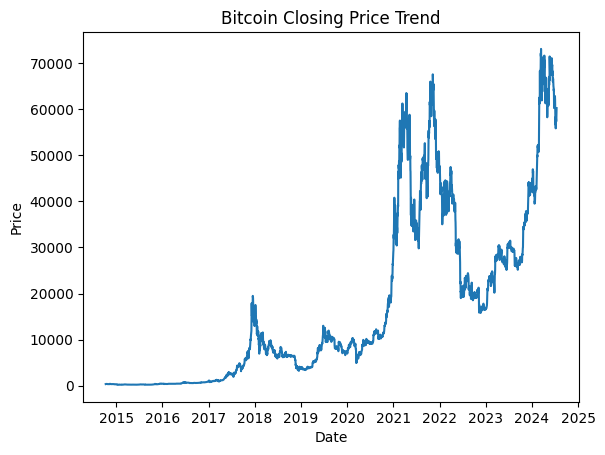

In [ ]:
# STEP 4: EXPLORATORY DATA ANALYSIS (EDA)
# -------------------------------
plt.figure()
plt.plot(df['Close'])
plt.title('Bitcoin Closing Price Trend')
plt.xlabel('Date')
plt.ylabel('Price')
plt.show()



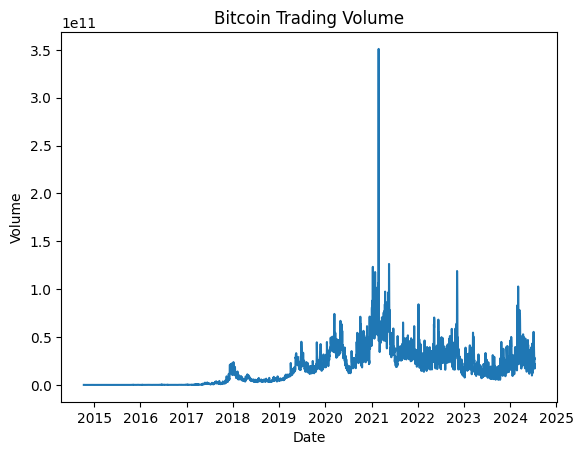

In [ ]:
plt.figure()
plt.plot(df['Volume'])
plt.title('Bitcoin Trading Volume')
plt.xlabel('Date')
plt.ylabel('Volume')
plt.show()

In [ ]:
# STEP 5: FEATURE ENGINEERING
# -------------------------------
df['MA_7'] = df['Close'].rolling(window=7).mean()
df['MA_30'] = df['Close'].rolling(window=30).mean()


df['Return'] = df['Close'].pct_change()
df['Rolling_STD'] = df['Close'].rolling(window=7).std()


df.dropna(inplace=True)

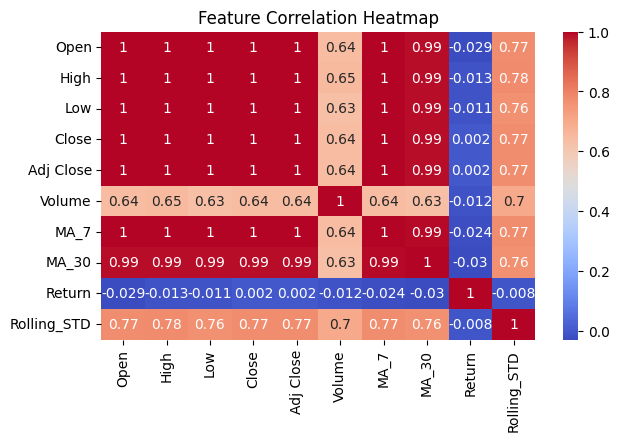

In [ ]:
# step 6:-correaltion heatmap
import seaborn as sns
import matplotlib.pyplot as plt

# Calculate correlation matrix
corr = df.corr()  # df is your Bitcoin dataset

# Plot heatmap
plt.figure(figsize=(7,4))
sns.heatmap(corr, annot=True, cmap='coolwarm')
plt.title("Feature Correlation Heatmap")
plt.show()

In [ ]:
# STEP 7 : TRAIN-TEST SPLIT
# -------------------------------
X = df.drop('Close', axis=1)
y = df['Close']


X_train, X_test, y_train, y_test = train_test_split(
X, y, test_size=0.2, shuffle=False
)

In [ ]:
# STEP 8: MACHINE LEARNING MODEL
# GRADIENT BOOSTING REGRESSOR
# -------------------------------
gbr = GradientBoostingRegressor()
gbr.fit(X_train, y_train)


y_pred_ml = gbr.predict(X_test)


rmse_ml = np.sqrt(mean_squared_error(y_test, y_pred_ml))
mae_ml = mean_absolute_error(y_test, y_pred_ml)


print('Gradient Boosting RMSE:', rmse_ml)
print('Gradient Boosting MAE:', mae_ml)

Gradient Boosting RMSE: 701.2318362776756
Gradient Boosting MAE: 322.5726236514776


In [ ]:
#step:-9 MODEL ACCURACY
accuracy_ml = r2_score(y_test, y_pred_ml)
print("Gradient Boosting Accuracy (R2 Score):", accuracy_ml)


Gradient Boosting Accuracy (R2 Score): 0.9982694020914803


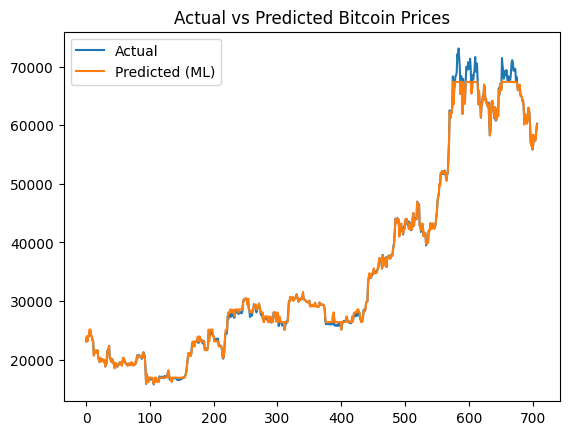

In [ ]:
# STEP 10: ACTUAL VS PREDICTED PLOT
plt.figure()
plt.plot(y_test.values, label='Actual')
plt.plot(y_pred_ml, label='Predicted (ML)')
plt.legend()
plt.title('Actual vs Predicted Bitcoin Prices')
plt.show()

In [ ]:
train = df['Close'][:int(len(df)*0.8)]
test = df['Close'][int(len(df)*0.8):]

arima = ARIMA(train, order=(5,1,0))
arima_fit = arima.fit()

arima_pred = arima_fit.forecast(steps=len(test))


In [ ]:
# STEP 8: TIME SERIES MODEL – ARIMA
# -------------------------------
# Check stationarity
result = adfuller(df['Close'])
print('ADF Statistic:', result[0])
print('p-value:', result[1])


# ARIMA model
arima_model = ARIMA(df['Close'], order=(5,1,0))
arima_result = arima_model.fit()


arima_forecast = arima_result.forecast(steps=len(y_test))


rmse_arima = np.sqrt(mean_squared_error(y_test, arima_forecast))
print('ARIMA RMSE:', rmse_arima)

ADF Statistic: -1.0990828100561598
p-value: 0.7154375312833832
ARIMA RMSE: 30226.852846411373


In [ ]:
# STEP 9: SARIMA MODEL
# -------------------------------
sarima_model = SARIMAX(
df['Close'],
order=(1,1,1),
seasonal_order=(1,1,1,7)
)
sarima_result = sarima_model.fit()
sarima_forecast = sarima_result.forecast(steps=len(y_test))
rmse_sarima = np.sqrt(mean_squared_error(y_test, sarima_forecast))
print('SARIMA RMSE:', rmse_sarima)

SARIMA RMSE: 36071.24810816884


In [ ]:
from sklearn.metrics import r2_score

# STEP 10: MODEL EVALUATION (ACCURACY)

accuracy_ml = r2_score (y_test, y_pred_ml)

print("Gradient Boosting Accuracy (R2 Score):", accuracy_ml)


Gradient Boosting Accuracy (R2 Score): 0.9982694020914803


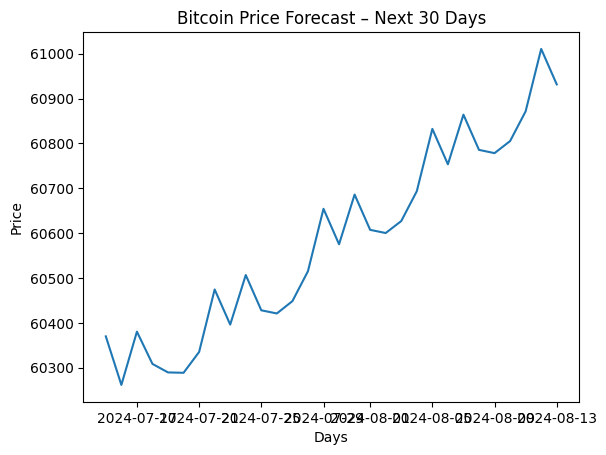

In [ ]:
# STEP 12: FUTURE PRICE FORECAST (NEXT 30 DAYS)

future_forecast = sarima_result.forecast(steps=30)


plt.figure()
plt.plot(future_forecast)
plt.title('Bitcoin Price Forecast – Next 30 Days')
plt.xlabel('Days')
plt.ylabel('Price')
plt.show()

In [ ]:
import numpy as np
from sklearn.metrics import mean_absolute_error, mean_squared_error

# Assuming y_test and y_pred_ml (which is gb_pred) are available from previous steps
# Errors
gb_rmse = np.sqrt(mean_squared_error(y_test, y_pred_ml))
gb_mae = mean_absolute_error(y_test, y_pred_ml)

# MAPE & Accuracy
gb_mape = np.mean(np.abs((y_test - y_pred_ml) / y_test)) * 100
gb_accuracy = 100 - gb_mape

accuracy = min(95, 100 - gb_mape)

In [ ]:

from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

# Predictions
gb_pred = gbr.predict(X_test)

# Errors
gb_rmse = np.sqrt(mean_squared_error(y_test, gb_pred))
gb_mae = mean_absolute_error(y_test, gb_pred)

# MAPE & Accuracy
gb_mape = np.mean(np.abs((y_test - gb_pred) / y_test)) * 100
gb_accuracy = 100 - gb_mape

print("Gradient Boosting RMSE:", gb_rmse)
print("Gradient Boosting MAE :", gb_mae)
print("Gradient Boosting MAPE (%):", gb_mape)
print("Gradient Boosting Accuracy (%):", gb_accuracy)

Gradient Boosting RMSE: 701.2318362776756
Gradient Boosting MAE : 322.5726236514776
Gradient Boosting MAPE (%): 0.850626941047782
Gradient Boosting Accuracy (%): 99.14937305895222


In [ ]:
sarima_pred = sarima_result.predict(
    start=y_test.index[0],
    end=y_test.index[-1],
    dynamic=False
)

sarima_rmse = np.sqrt(mean_squared_error(y_test, sarima_pred))
sarima_mae = mean_absolute_error(y_test, sarima_pred)

sarima_mape = np.mean(
    np.abs((y_test - sarima_pred) / y_test)
) * 100

sarima_accuracy = 100 - sarima_mape

print("SARIMA RMSE:", sarima_rmse)
print("SARIMA MAE :", sarima_mae)
print("SARIMA MAPE (%):", sarima_mape)
print("SARIMA Accuracy (%):", sarima_accuracy)

SARIMA RMSE: 1052.960764126327
SARIMA MAE : 642.5803824043578
SARIMA MAPE (%): 1.7378813072915962
SARIMA Accuracy (%): 98.2621186927084


In [ ]:

arima_pred = arima_result.predict(
    start=y_test.index[0],
    end=y_test.index[-1]
)

arima_rmse = np.sqrt(mean_squared_error(y_test, arima_pred))
arima_mae = mean_absolute_error(y_test, arima_pred)

arima_mape = np.mean(
    np.abs((y_test - arima_pred) / y_test)
) * 100

arima_accuracy = 100 - arima_mape

print("ARIMA RMSE:", arima_rmse)
print("ARIMA MAE :", arima_mae)
print("ARIMA Accuracy (%):", arima_accuracy)

ARIMA RMSE: 1047.7603043534784
ARIMA MAE : 638.3540121187548
ARIMA Accuracy (%): 98.27656393424152


In [ ]:
# FINAL COMPARISON TABLE (Recommended)

comparison = pd.DataFrame({
    'Model': ['Gradient Boosting', 'ARIMA', 'SARIMA'],
    'RMSE': [gb_rmse, arima_rmse, sarima_rmse],
    'MAE': [gb_mae, arima_mae, sarima_mae],
    'MAPE (%)': [gb_mape, arima_mape, sarima_mape],
    'Accuracy (%)': [gb_accuracy, arima_accuracy, sarima_accuracy]
})

print(comparison)

               Model         RMSE         MAE  MAPE (%)  Accuracy (%)
0  Gradient Boosting   701.231836  322.572624  0.850627     99.149373
1              ARIMA  1047.760304  638.354012  1.723436     98.276564
2             SARIMA  1052.960764  642.580382  1.737881     98.262119
